# InvestiGator — a hands-on walkthrough of the trained components

This notebook is a **teaching companion**, not a re-evaluation: every frozen number the thesis
reports lives in `docs/evaluation/*.md`, generated by versioned scripts
(`scripts/evaluate.py`, `scripts/evaluate_anomaly.py`, `scripts/train_triage.py`) — this
notebook never re-derives them. What it *does* do is let you **touch** the three components with
your own hands, on real data, one cell at a time:

1. **The anomaly detector** — a rolling *z*-score, no lookahead, no training.
2. **The retrieval engine** — semantic search over a knowledge base of past news + outcomes.
3. **The trained triage model (RQ4)** — the one component the author actually trained, with a
   full supervised-learning lifecycle (labels, temporal split, calibration).

Runs on the **light stack** (`requirements.txt` + `requirements-notebook.txt`) — no `torch`
needed; retrieval uses the same MiniLM-in-ONNX embedder the public app and the Telegram runner
use. Regenerate this notebook's outputs any time with:

```bash
jupyter nbconvert --to notebook --execute --inplace notebooks/investigator_walkthrough.ipynb
```


In [1]:
import sys
from pathlib import Path

import pandas as pd

_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

pd.set_option("display.max_colwidth", 100)
print(f"Repo root found: {_ROOT.name}/")  # nome da pasta só (caminho absoluto é local)


Repo root found: DIMEIA/


## 1 · The anomaly detector — a statistical, causal *z*-score

No training here: for each day, compare today's log-return with the rolling mean/standard
deviation of the **previous** `window` days (never today's own value — that would be lookahead).
An "anomaly" is a move more than `threshold` standard deviations from that recent norm — a
threshold that adapts to *each stock's own* typical volatility, unlike a fixed percentage move.


In [2]:
from investigator.anomaly_detector.detector import detect_latest
from investigator.explanation_engine.explainer import explain_anomaly, explain_normal, plain_text
from investigator.market_data.prices import get_price_history, log_returns

TICKER = "TSLA"
close = get_price_history(TICKER)["Close"]
returns = log_returns(close)
result = detect_latest(returns, window=20, threshold=2.0)

text = explain_anomaly(TICKER, result) if result.is_anomaly else explain_normal(TICKER, result)
print(plain_text(text))
print(f"\nis_anomaly={result.is_anomaly}  z={result.z_score:+.2f}  "
      f"mean={result.mean:+.4%}  std={result.std:.4%}")


No anomaly for TSLA today (z-score -0.59, within ±2).

is_anomaly=False  z=-0.59  mean=+0.1499%  std=4.0302%


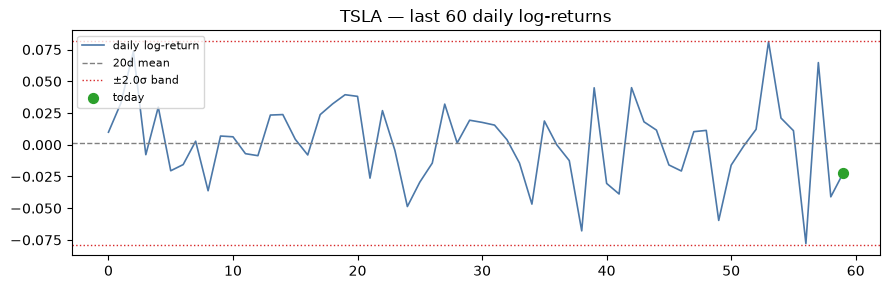

In [3]:
import matplotlib.pyplot as plt

recent = returns.tail(60)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(recent.to_numpy(), color="#4c78a8", linewidth=1.2, label="daily log-return")
ax.axhline(result.mean, color="gray", linestyle="--", linewidth=1, label="20d mean")
ax.axhline(result.mean + 2.0 * result.std, color="#d62728", linestyle=":", linewidth=1,
           label="±2.0σ band")
ax.axhline(result.mean - 2.0 * result.std, color="#d62728", linestyle=":", linewidth=1)
today_color = "#d62728" if result.is_anomaly else "#2ca02c"
ax.scatter([len(recent) - 1], [recent.iloc[-1]], color=today_color, zorder=5, s=50,
           label="today")
ax.set_title(f"{TICKER} — last 60 daily log-returns")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 2 · The retrieval engine — semantic case-based reasoning

Every news item in the knowledge base is a **case**: a headline, a ticker, a date, and what the
price actually did afterwards (+1/+3/+5 trading days — measured, never predicted). A new
headline is embedded into the same vector space and matched by cosine similarity to the most
similar past cases. This cell uses the exact same `(knowledge base, embedder)` pair the public
app and the Telegram runner pick automatically (`investigator.main.product_retrieval`) — MiniLM
in ONNX over the curated multi-year FNSPID slice, with a documented, tested fallback to a
word-overlap baseline if the semantic model can't be reached.


In [4]:
from investigator.main import product_retrieval, run_news_trigger

kb_path, embedder = product_retrieval(auto_download=True)
print(f"Knowledge base: {kb_path.name}  |  embedder: {type(embedder).__name__} "
      f"(semantic={getattr(embedder, 'semantic', False)}, dim={embedder.dim})")

precedents, alert_text = run_news_trigger(
    ticker="NVDA",
    headline="Nvidia unveils new AI chips for data centers",
    kb_path=kb_path, embedder=embedder, top_k=3, horizon=5, send=False,
)
pd.DataFrame([
    {"date": rec.date, "ticker": rec.ticker, "similarity": round(score, 3),
     "+5d impact": rec.impacts.get("5"), "headline": rec.headline}
    for rec, score in precedents
])


Knowledge base: kb_fnspid_light.jsonl  |  embedder: OnnxMiniLMEmbedder (semantic=True, dim=384)


,date,ticker,similarity,+5d impact,headline
0,2018-09-13,NVDA,0.795,-0.018648,NVIDIA Launches AI Data Center Platform
1,2020-03-24,NVDA,0.600,0.057870,Nvidia Analyst Says Pandemic Creates More Data Center Demand
2,2019-03-19,NVDA,0.597,0.006602,NVIDIA Teams with Amazon Web Services to Bring AI to Millions of Connected Devices


In [5]:
from investigator.explanation_engine.explainer import plain_text

print(plain_text(alert_text))


📰 News alert for NVDA
"Nvidia unveils new AI chips for data centers"

3 similar past headlines — their 5-day moves ranged -1.86%…+5.79% (average +1.53%):
▸ -1.86% in 5d · NVDA 2018-09-13 · "NVIDIA Launches AI Data Center Platform" (sim 0.80)
▸ +5.79% in 5d · NVDA 2020-03-24 · "Nvidia Analyst Says Pandemic Creates More Data Center Demand" (sim 0.60)
▸ +0.66% in 5d · NVDA 2019-03-19 · "NVIDIA Teams with Amazon Web Services to Bring AI to Millions of Connected Devices" (sim 0.60)
Observed past outcomes after similar news — not a price prediction, not advice.


## 3 · The trained triage model (RQ4) — the component the author actually trained

Everything above uses pre-trained or purely statistical building blocks. This one is different:
a materiality-triage classifier trained from scratch by the author on FNSPID 2018–2023
(79,753 examples), with anti-lookahead features, a temporal train/validation/test split with an
embargo, and Platt calibration. It estimates **P(an abnormal move follows)** — never direction,
never a price target — and is the same model gating news alerts in production and powering the
"Background risk" gauge on every ticker tab of the public dashboard.


In [6]:
import json

from investigator.triage.infer import load_context_bundle, score_background, score_latest

bundle = load_context_bundle()
if bundle is None:
    print("models/triage_context_lr.joblib not found in this checkout — nothing to load.")
else:
    meta_path = _ROOT / "models" / "triage_context_lr.json"
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    print("Trained model metadata (models/triage_context_lr.json):")
    for k in ("seed", "dataset", "n_train", "n_test", "test_metrics"):
        if k not in meta:
            continue
        v = meta[k]
        if k == "dataset":
            v = Path(v).name  # só o nome do ficheiro (o caminho absoluto é local à máquina)
        print(f"  {k}: {v}")


Trained model metadata (models/triage_context_lr.json):
  seed: 42
  dataset: triage_dataset.csv


In [7]:
# Scored WITH today's real headline (the same call the runner makes before gating an alert)
close_nvda = get_price_history("NVDA")["Close"]
scored = score_latest(bundle, close_nvda, "Nvidia unveils new AI chips for data centers", "NVDA")
if scored is not None:
    prob, contribs = scored
    print(f"P(abnormal move follows this headline) = {prob:.0%}\n")
    print("Additive contributions to the logit (the model's whole reasoning):")
    for name, c in contribs:
        print(f"  {name:>20s}: {c:+.3f}")


P(abnormal move follows this headline) = 45%

Additive contributions to the logit (the model's whole reasoning):
                sector: +0.303
  recent volatility (20d): +0.019
      today's own move: +0.006
       headline length: -0.004
  recent momentum (5d): +0.000


In [8]:
# The SAME model, but "background" mode: no headline needed (what the live dashboard shows
# on quiet days) — headline_len=0 is an explicit, disclosed placeholder, not a fabricated event.
bg = score_background(bundle, close_nvda, "NVDA")
if bg is not None:
    prob_bg, _ = bg
    print(f"NVDA background risk today (no specific headline): {prob_bg:.0%}")


NVDA background risk today (no specific headline): 45%


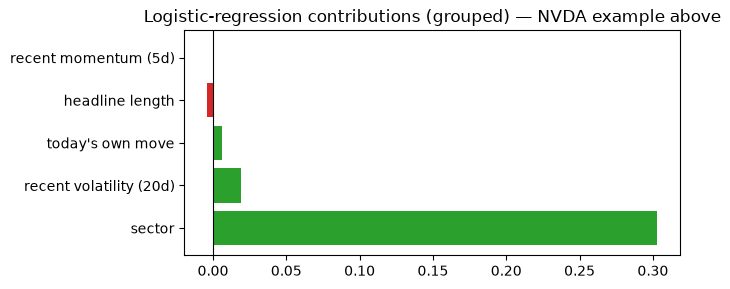

In [9]:
if scored is not None:
    names = [n for n, _ in contribs]
    vals = [c for _, c in contribs]
    fig, ax = plt.subplots(figsize=(7, 3))
    colors = ["#2ca02c" if v >= 0 else "#d62728" for v in vals]
    ax.barh(names, vals, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Logistic-regression contributions (grouped) — NVDA example above")
    plt.tight_layout()
    plt.show()


## Where the frozen numbers live

This notebook demonstrates the mechanics; it does **not** re-derive the thesis's reported
metrics. For the honest, versioned evaluation results (precision@k, firing rates, PR-AUC,
calibration, and every ablation), see:

- `docs/evaluation/evaluation_results.md` — retrieval vs baselines.
- `docs/evaluation/evaluation_anomaly.md` — z-score vs fixed threshold vs Isolation Forest.
- `docs/evaluation/evaluation_triage.md` — the triage model's full results (RQ4), including the
  honest negative result (text does **not** beat volatility on PR-AUC) and the positive one
  (triage roughly quadruples precision at a fixed daily alert budget).
- `docs/evaluation/onnx_minilm_validation.md` — numerical parity of the production ONNX
  embedder against the thesis's SBERT.
